In [41]:
!pip install gensim


In [42]:
import gensim

import gensim.downloader

Part 1: Word Embeddings

In [43]:
# Load pre-trained Word2Vec model trained on wikipedia data

model = gensim.downloader.load("glove-wiki-gigaword-100")
# Getting the vector for a word

dog = model['dog']

# Getting the most similar words

print(model.most_similar('dog'))

# Getting the similarity between two words

print(model.similarity('dog', 'cat'))


[('cat', 0.8798074126243591), ('dogs', 0.8344309329986572), ('pet', 0.7449564337730408), ('puppy', 0.7236376404762268), ('horse', 0.7109653949737549), ('animal', 0.6817063093185425), ('pig', 0.655417263507843), ('boy', 0.6545307636260986), ('cats', 0.6471933126449585), ('rabbit', 0.6468630433082581)]
0.87980753


Part 1a

In [44]:

#find the most similar words to a word of your choice. 
#Does the result make sense? Look up some of the words if you don't know them
#Share and discuss with your group

chosen_word = 'game'
similar_words = model.most_similar(chosen_word)
print(f"Most similar words to '{chosen_word}':", similar_words)

Most similar words to 'game': [('games', 0.8644919991493225), ('play', 0.8316268920898438), ('season', 0.7733193635940552), ('player', 0.7579817175865173), ('players', 0.7287797927856445), ('match', 0.7282912135124207), ('scoring', 0.7201363444328308), ('playing', 0.7145521640777588), ('playoffs', 0.7068413496017456), ('team', 0.7012254595756531)]


The word “game” often relates to sports, competition, and activities involving players and teams. The similar terms reflect these associations well, suggesting the model accurately captures the context in which “game” is commonly used.

In [45]:

#we can extract a "capital vector" by subtracting the vector for a country from the vector for its capital
capital= model["berlin"]-model['germany']

fra_capital=model["france"]+capital

print(model.most_similar(fra_capital))
#likewise, we can extract a "plural vector" by subtracting the vector for a singular noun from the vector for its plural
plural=model["cats"]-model["cat"]

print(model.most_similar(plural))

#we can also add vectors together
plural_dogs=model["dog"]+plural

print(model.most_similar(plural_dogs))



[('paris', 0.8827143311500549), ('france', 0.755802571773529), ('french', 0.7075165510177612), ('prohertrib', 0.6943174600601196), ('berlin', 0.6665561199188232), ('brussels', 0.6574430465698242), ('lyon', 0.6526200771331787), ('london', 0.64079749584198), ('le', 0.6403627991676331), ('strasbourg', 0.6346526145935059)]
[('lowlanders', 0.4844588041305542), ('zebras', 0.45914992690086365), ('dicots', 0.45332765579223633), ('non-arabs', 0.45208773016929626), ('amerindians', 0.4478238821029663), ('buffalos', 0.4475123882293701), ('giraffes', 0.4466330111026764), ('bavarians', 0.4452260732650757), ('welshmen', 0.4440663158893585), ('dingos', 0.44403281807899475)]
[('dogs', 0.8921768665313721), ('cats', 0.8814380764961243), ('dog', 0.7873795628547668), ('animals', 0.7512702345848083), ('pets', 0.7392118573188782), ('cows', 0.6835324168205261), ('pet', 0.679297685623169), ('horses', 0.6774964332580566), ('pigs', 0.6755765080451965), ('animal', 0.6683686971664429)]


In [46]:
# this can be used to find examples of data bias in word embeddings

# for example, we can find the most similar words to "doctor" and "nurse"

gender=model["woman"]-model["man"]

print(model.most_similar(gender))
print(model.most_similar(-gender))

model.most_similar(model["doctor"]+gender)



[('menstruating', 0.6102039813995361), ('miscarry', 0.5550354719161987), ('lactating', 0.542172908782959), ('pre-eclampsia', 0.5129693746566772), ('uterus', 0.5093088746070862), ('ovulating', 0.5070309042930603), ('miscarried', 0.5043483376502991), ('adoptee', 0.5012543201446533), ('comnena', 0.5012539625167847), ('pulecio', 0.500389039516449)]
[('arsene', 0.4388486444950104), ('ancelotti', 0.42151397466659546), ('nistelrooy', 0.41140034794807434), ('strachan', 0.4089668393135071), ('rafa', 0.40728434920310974), ('technicals', 0.4060872495174408), ('allardyce', 0.4018688201904297), ('boss', 0.40107354521751404), ('rangers', 0.39962300658226013), ('utd', 0.3967454135417938)]


[('doctor', 0.8661209940910339),
 ('nurse', 0.7757077813148499),
 ('physician', 0.7128061652183533),
 ('woman', 0.7089030742645264),
 ('doctors', 0.6793617010116577),
 ('pregnant', 0.6787967085838318),
 ('patient', 0.6772218346595764),
 ('dentist', 0.6694242358207703),
 ('mother', 0.6586815714836121),
 ('medical', 0.6466937065124512)]

Part 1b

In [47]:
#try to isolate a specific dimension in the embeddings and add it to multiple words. 
#does this show any bias or assumptions in the data? 
# Discuss with your group and share most interesting dimension in the document

capital_vector = model['berlin'] - model['germany']
france_capital = model['france'] + capital_vector
similar_words_capital = model.most_similar(france_capital)
print("Predicted capital of France:", similar_words_capital)
plural_vector = model['cats'] - model['cat']
plural_dog = model['dog'] + plural_vector
similar_words_plural = model.most_similar(plural_dog)
print("Predicted plural of 'dog':", similar_words_plural)

Predicted capital of France: [('paris', 0.8827143311500549), ('france', 0.755802571773529), ('french', 0.7075165510177612), ('prohertrib', 0.6943174600601196), ('berlin', 0.6665561199188232), ('brussels', 0.6574430465698242), ('lyon', 0.6526200771331787), ('london', 0.64079749584198), ('le', 0.6403627991676331), ('strasbourg', 0.6346526145935059)]
Predicted plural of 'dog': [('dogs', 0.8921768665313721), ('cats', 0.8814380764961243), ('dog', 0.7873795628547668), ('animals', 0.7512702345848083), ('pets', 0.7392118573188782), ('cows', 0.6835324168205261), ('pet', 0.679297685623169), ('horses', 0.6774964332580566), ('pigs', 0.6755765080451965), ('animal', 0.6683686971664429)]


Part 2: Visualization and Embeddings in Space

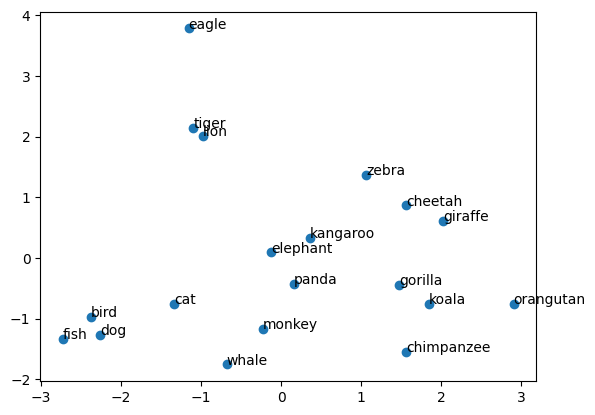

In [48]:
#visualize pca of word embeddings

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

words=["dog","cat","fish", "whale", "bird", "eagle", "lion", "tiger", "cheetah", "elephant", "giraffe", "zebra", "kangaroo", "koala", "panda", "monkey", "gorilla", "chimpanzee", "orangutan", ]

X=[model[word] for word in words]

#identify clusters of words in the word embeddings at high dimensions

pca=PCA(n_components=2)

X_pca=pca.fit_transform(X)

plt.scatter(X_pca[:,0],X_pca[:,1])

for i, word in enumerate(words):
    plt.annotate(word, (X_pca[i,0],X_pca[i,1]))

plt.show()

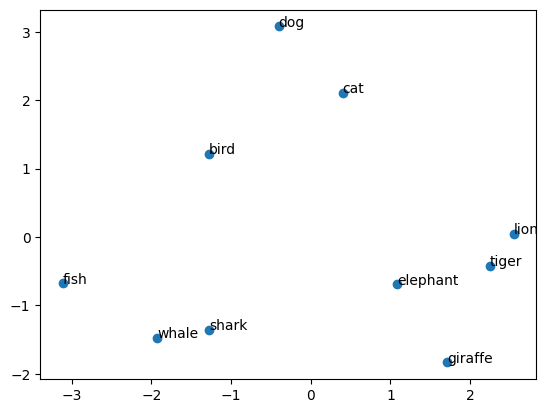

In [49]:
#repeat this process with your own set of 10-20 words. 
#Does the proximity between words and overall distances make sense? Work as a group and discuss your individual findings.

words = ["dog", "cat", "fish", "bird", "lion", "tiger", "elephant", "giraffe", "whale", "shark"]

X=[model[word] for word in words]

pca=PCA(n_components=2)

X_pca=pca.fit_transform(X)

plt.scatter(X_pca[:,0],X_pca[:,1])

for i, word in enumerate(words):
    plt.annotate(word, (X_pca[i,0],X_pca[i,1]))

plt.show()


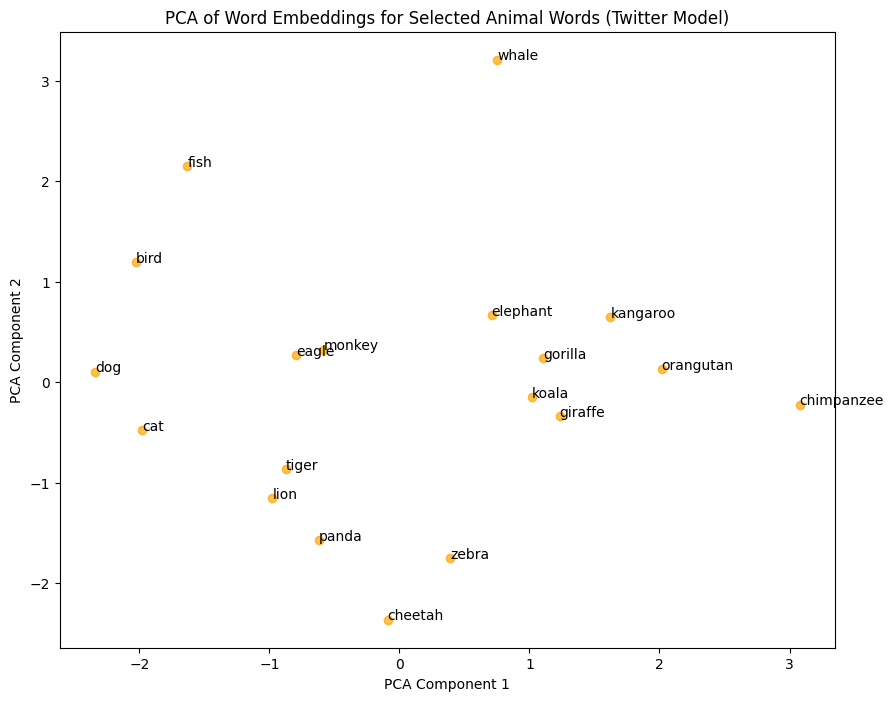

In [50]:
# repeat the process with a different pre-trained model and the same set of words. 
# What has changed in the embedding space? What might this have to do with the training data?
twitter_model= gensim.downloader.load("glove-twitter-100")
words = ["dog", "cat", "fish", "whale", "bird", "eagle", "lion", "tiger", "cheetah",
         "elephant", "giraffe", "zebra", "kangaroo", "koala", "panda", "monkey",
         "gorilla", "chimpanzee", "orangutan"]

X_twitter = [twitter_model[word] for word in words]

pca_twitter = PCA(n_components=2)
X_pca_twitter = pca_twitter.fit_transform(X_twitter)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca_twitter[:, 0], X_pca_twitter[:, 1], color='orange', alpha=0.7)

for i, word in enumerate(words):
    plt.annotate(word, (X_pca_twitter[i, 0], X_pca_twitter[i, 1]))

plt.title("PCA of Word Embeddings for Selected Animal Words (Twitter Model)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

Part 3: Embedding reddit posts

In [51]:
#read in uiuc csv
import pandas as pd
uiuc=pd.read_csv("uiuc.csv")
mich=pd.read_csv("umich.csv")

#sample so we have even number of samples from each dataset
mich=mich.sample(n=4725)

#assign labels based on origin subreddit of comment
uiuc['label']=1
mich['label']=0

#you will be working with the data csv for the rest of the question
data=pd.concat([uiuc,mich])




In [52]:
#using the code from project 1, clean the text and create a bag of words representation of the text
def clean(text):
    text = ' '.join(text.split())
    text = text.lower()
    text = ''.join([char for char in text if char.isalpha() or char.isspace()])
    return text

data['cleaned_text'] = data['text'].apply(clean)

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
bag_of_words = vectorizer.fit_transform(data['cleaned_text'])

bow_df = pd.DataFrame(bag_of_words.toarray(), columns=vectorizer.get_feature_names_out())

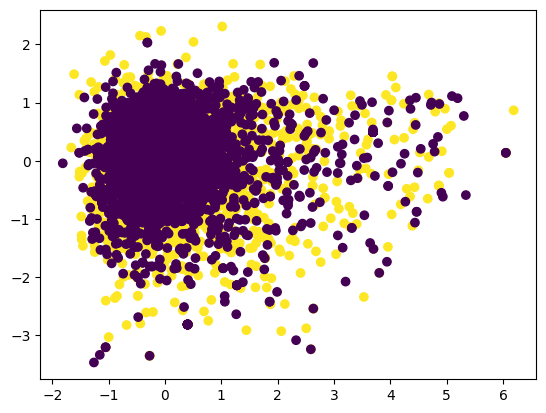

In [53]:
#using the embedding code from last week, plot a pca of all posts in the subreddits data set

#color by the "label" column to see if the two subreddits are separable in the embedding space

# is there a clear separation between the two columns? 

import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def avg_embedding(sentence, model):
    words = sentence.split()
    embeddings = [model[word] for word in words if word in model]
    if embeddings:
        return np.mean(embeddings, axis=0)
    else:
        return np.nan

data['avg_embedding'] = data['cleaned_text'].apply(lambda x: avg_embedding(x, model))

avg_embeddings = [embedding for embedding in data['avg_embedding'] if not np.isnan(embedding).any()]

pca = PCA(n_components=2)
pca_components = pca.fit_transform(avg_embeddings)


plt.scatter(pca_components[:, 0], pca_components[:, 1], c=data['label'].iloc[:len(avg_embeddings)])
plt.show()

no significant difference

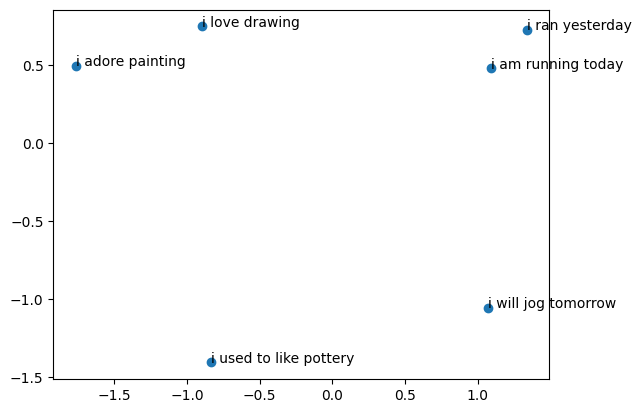

In [54]:
#here is a function to calculate the average embedding of a cleaned document
import numpy as np
#we can sum together all the embeddings to get a representation of all the concepts expressed in the document
def avg_embedding(sentence, model):
    words=sentence.split()
    embeddings=[model[word] for word in words if word in model]
    return np.mean(embeddings, axis=0)

sentences=["i am running today", "i will jog tomorrow", "i ran yesterday", "i love drawing", "i adore painting", "i used to like pottery"]

#we can then calculate the average embedding of each sentence

avg_embeddings=[avg_embedding(sentence, model) for sentence in sentences]

#we can then plot the pca of these embeddings

pca=PCA(n_components=2)

X_pca=pca.fit_transform(avg_embeddings)

plt.scatter(X_pca[:,0],X_pca[:,1])

for i, sentence in enumerate(sentences):
    plt.annotate(sentence, (X_pca[i,0],X_pca[i,1]))

plt.show()

In [55]:

#use this function to calculate the average embedding of each post in the dataset

#plot the pca of the average embeddings, color by the "label" column

#how is this plot different from the previous one?

#is there clear separation? 


In this plot, we observe a more diffuse distribution of points with some clustering, but not as distinct as the bag-of-words PCA. Using average word embeddings captures semantic similarities between posts, potentially allowing for more nuanced groupings based on meaning, rather than exact word matches. This approach reflects more abstract relationships compared to bag-of-words, which directly counts word frequencies. There is no strong or clear separation between the two groups (UIUC and Michigan) based on the color-coded points. The points from both subreddits overlap significantly, indicating that the semantic content of posts from each subreddit may be quite similar. This overlap suggests that, in this dataset, average embeddings alone may not be sufficient to distinguish between the two subreddits based on content.

Part 4: HuggingFace and BERT

In [58]:
!pip install torch
!pip install transformers
!pip install tensorflow

import torch
import tensorflow as tf
print(f"PyTorch version: {torch.__version__}")
print(f"TensorFlow version: {tf.__version__}")

PyTorch version: 2.5.1
TensorFlow version: 2.18.0


In [64]:
#Please wait until after next week to start

# Use a pipeline as a high-level helper
import torch
import tensorflow
from transformers import AutoTokenizer, AutoModelForSequenceClassification
pipe = pipeline("text-classification", model="finiteautomata/bertweet-base-sentiment-analysis", device=0)  # GPU


RuntimeError: At least one of TensorFlow 2.0 or PyTorch should be installed. To install TensorFlow 2.0, read the instructions at https://www.tensorflow.org/install/ To install PyTorch, read the instructions at https://pytorch.org/.

In [40]:
#use the pipeline to classify the sentiment of a sentence of your choice
pipe("I love this class")

NameError: name 'pipe' is not defined

In [37]:
#use the pipeline to classify the sentiment of all posts in the reddit dataset
#report the most common sentiment label

data['sentiment'] = data['cleaned_text'].apply(lambda x: pipe(x)[0]['label'])
most_common_sentiment = data['sentiment'].value_counts().idxmax()
print("Most common sentiment label:", most_common_sentiment)

NameError: name 'pipe' is not defined

In [38]:
#look at ten sample posts and labels; do you agree with all of them? 

sample_posts = data[['cleaned_text', 'sentiment']].sample(10)
print(sample_posts)

KeyError: "['sentiment'] not in index"

In [39]:
#is the UIUC or Michigan subreddit more negative?

uiuc_negativity = data[data['label'] == 1]['sentiment'].value_counts(normalize=True).get('NEG', 0)
michigan_negativity = data[data['label'] == 0]['sentiment'].value_counts(normalize=True).get('NEG', 0)

if uiuc_negativity > michigan_negativity:
    print("UIUC subreddit is more negative.")
elif michigan_negativity > uiuc_negativity:
    print("Michigan subreddit is more negative.")
else:
    print("Both subreddits have similar negativity levels.")

KeyError: 'sentiment'